In [1]:
import pandas as pd
import numpy as np

import torch
from torch import nn
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv

In [2]:
import random

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)

In [3]:
import geopandas as gpd
from libpysal.weights import Queen

gdf = gpd.read_file("../Output/Geo Output/London_LSOA_2021.shp").sort_values("LSOA21CD").reset_index(drop=True)

w = Queen.from_dataframe(gdf)
edges, weights = [], []

for src, neighbors in w.neighbors.items():
    for tgt in neighbors:
        geom_src = gdf.geometry.iloc[src]
        geom_tgt = gdf.geometry.iloc[tgt]
        inter = geom_src.intersection(geom_tgt)
        weight = inter.length if inter.length > 0 else 0.001
        edges.append([src, tgt])
        weights.append(weight)
        edges.append([tgt, src])
        weights.append(weight)
        
edge_index = torch.tensor(edges, dtype=torch.long).T
edge_weight = torch.tensor(weights, dtype=torch.float32)

C:\Users\wbwha\AppData\Local\Temp\ipykernel_30972\3828378298.py:6: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf)


In [14]:
X_train_origin = torch.load("../Output/Pred Input/topic_top200_train.pt")
y_train = torch.load("../Output/Pred Input/y_train_5.pt")

X_train = X_train_origin['X']

In [15]:
from sklearn.model_selection import train_test_split

from collections import defaultdict

y_np = y_train.cpu().numpy()

lsoa_indices = np.arange(len(y_np))

train_idx = []
val_idx = []

for label in np.unique(y_np):

    class_indices = np.where(y_np == label)[0]
    n = len(class_indices)
    n_val = max(1, int(n * 0.2))
    shuffled = np.random.RandomState(seed=42).permutation(class_indices)
    val_idx.extend(shuffled[:n_val])
    train_idx.extend(shuffled[n_val:])

train_idx = np.array(train_idx)
val_idx = np.array(val_idx)

train_mask = torch.zeros(len(y_train), dtype=torch.bool)
val_mask = torch.zeros(len(y_train), dtype=torch.bool)
train_mask[train_idx] = True
val_mask[val_idx] = True

from sklearn.metrics import classification_report, accuracy_score

from Hybrid_Models.Gen_GCN_LSTM_MLP import GentrificationGCN_LSTM

in_channels = X_train.shape[2]

lstm_hidden = 64
gcn_hidden = 64

dropout_rate = 0.3

num_classes = len(np.unique(y_train.cpu().numpy()))

model = GentrificationGCN_LSTM(in_channels, lstm_hidden, gcn_hidden, dropout_rate, num_classes).to(X_train.device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=5e-4)

from sklearn.utils.class_weight import compute_class_weight

y_train_part = y_np[train_idx]
classes_present = np.unique(y_train_part)

weights_partial = compute_class_weight(class_weight='balanced', classes=classes_present, y=y_train_part)

n_classes = len(np.unique(y_train))
full_weights = np.zeros(n_classes)

for i, cls in enumerate(classes_present):
    full_weights[cls] = weights_partial[i]

class_weights_tensor = torch.tensor(full_weights, dtype=torch.float32).to(X_train.device)

from Loss_Functions.Focal_Loss import FocalLossMultiClass

# criterion = FocalLossMultiClass(alpha=class_weights_tensor, gamma=2.0)
criterion = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)

import matplotlib.pyplot as plt

epochs = range(1, 101)

for epoch in epochs:

    model.train()
    optimizer.zero_grad()
    out = model(X_train, edge_index, edge_weight)
    loss = criterion(out[train_mask], y_train[train_mask])
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0 or epoch == 1:

        model.eval()

        with torch.no_grad():
            
            # out_val = model(X_train_nlp, edge_index, edge_weight)
            preds = out[val_mask].argmax(dim=1)
            acc = (preds == y_train[val_mask]).float().mean ().item()
            print(f"Epoch {epoch:03d} | Val Acc: {acc:.4f}")

from sklearn.metrics import classification_report

model.eval()

with torch.no_grad():

    out = model(X_train, edge_index, edge_weight)
    # out_val = model(X_train_nlp, edge_index, edge_weight)
    y_true = y_train[val_mask].cpu().numpy()
    y_pred = out[val_mask].argmax(dim=1).cpu().numpy()

print("\n"+classification_report(y_true, y_pred, digits=4, zero_division=0))

Epoch 001 | Val Acc: 0.1365
Epoch 010 | Val Acc: 0.3845
Epoch 020 | Val Acc: 0.4478
Epoch 030 | Val Acc: 0.4880
Epoch 040 | Val Acc: 0.5131
Epoch 050 | Val Acc: 0.5321
Epoch 060 | Val Acc: 0.5261
Epoch 070 | Val Acc: 0.5301
Epoch 080 | Val Acc: 0.5161
Epoch 090 | Val Acc: 0.5070
Epoch 100 | Val Acc: 0.5080

              precision    recall  f1-score   support

           0     0.7961    0.7253    0.7590       506
           1     0.3441    0.2520    0.2909       127
           2     0.2331    0.3551    0.2815       107
           3     0.3356    0.3472    0.3413       144
           4     0.2923    0.3393    0.3140       112

    accuracy                         0.5271       996
   macro avg     0.4002    0.4038    0.3974       996
weighted avg     0.5547    0.5271    0.5376       996



In [ ]:
import itertools, random, numpy as np, torch
from sklearn.metrics import f1_score, classification_report, accuracy_score, recall_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt

# Reproducible repeated runs (only model/dropout randomness varies; split can be fixed)
seeds = [0, 1, 2]  # Increase if compute allows, e.g. [0,1,2,3,4]
num_epochs = 100
eval_every = 5

# Early Stopping config
early_stop_patience = 10          # Number of eval steps with no improvement before stopping
early_stop_min_delta = 1e-4       # Minimum improvement in monitored metric to reset patience
monitor_metric = "val_macro_f1"   # We focus on macro-F1 for class balance

# ---- Optional K-Fold over nodes (NEW): set to >1 to enable. Will ignore your fixed split. ----
N_FOLDS = 0  # 0/1 = disabled (use your existing train_mask/val_mask); set to 3 for 3-fold CV

#Search space
search_space = {
    "lstm_hidden": [64, 128],
    "gcn_hidden":  [64, 128],
    "dropout":     [0.2, 0.4],
    "lr":          [1e-3, 3e-4],
    "weight_decay":[5e-4, 1e-4],
    "focal_gamma": [1.0, 2.0]   # used only by FocalLoss
}

loss_names = ["ce", "focal"]

device = X_train_nlp.device
n_classes = int(len(np.unique(y_train.cpu().numpy())))
in_channels = X_train_nlp.shape[2]

# Build folds: either use your fixed masks, or create K-Fold masks over nodes
fold_masks = []
if N_FOLDS and N_FOLDS > 1:
    # Create stratified K-folds over node indices based on y labels
    indices = np.arange(len(y_np))
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    for fold_id, (tr_idx, va_idx) in enumerate(skf.split(indices, y_np), 1):
        tr_mask = torch.zeros(len(y_train), dtype=torch.bool, device=device)
        va_mask = torch.zeros(len(y_train), dtype=torch.bool, device=device)
        tr_mask[tr_idx] = True
        va_mask[va_idx] = True
        fold_masks.append((tr_mask, va_mask))
else:
    # Use the user-provided fixed split
    fold_masks.append((train_mask.to(device), val_mask.to(device)))

def train_one_run(cfg, seed, loss_name, tr_mask, va_mask):
    # Deterministic-ish behavior
    torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

    # Build model fresh for this run
    model = GentrificationGCN_LSTM(
        in_channels, cfg["lstm_hidden"], cfg["gcn_hidden"], cfg["dropout"], n_classes
    ).to(device)

    # Optimizer
    optimizer = torch.optim.Adam(
        model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"]
    )

    # Criterion by name
    if loss_name == "ce":
        criterion = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)
    elif loss_name == "focal":
        criterion = FocalLossMultiClass(alpha=class_weights_tensor, gamma=cfg["focal_gamma"])
    elif loss_name == "label_smooth":
        criterion = torch.nn.CrossEntropyLoss(
            weight=class_weights_tensor, label_smoothing=cfg["label_smoothing"]
        )
    else:
        raise ValueError(f"Unknown loss: {loss_name}")

    # Training history
    history = {
        "epoch": [],
        "train_loss": [],
        "val_loss": [],
        "val_acc": [],
        "val_macro_f1": [],
        "val_weighted_f1": [],
        "val_macro_recall": [],  # macro recall (focus on minority classes)
    }

    # Early stopping state (monitor val_macro_f1 by default)
    best_metric = -1.0
    best_state = None
    best_epoch = 0
    no_improve = 0

    # Training loop
    for epoch in range(1, num_epochs + 1):
        model.train()
        optimizer.zero_grad()
        out = model(X_train_nlp, edge_index, edge_weight)                 # [N, C]
        loss = criterion(out[tr_mask], y_train[tr_mask])
        loss.backward()
        optimizer.step()

        # Periodic evaluation
        if (epoch % eval_every == 0) or (epoch == 1) or (epoch == num_epochs):
            model.eval()
            with torch.no_grad():
                out_eval = model(X_train_nlp, edge_index, edge_weight)
                logits_val = out_eval[va_mask]
                y_val_true = y_train[va_mask].cpu().numpy()
                y_val_pred = logits_val.argmax(dim=1).cpu().numpy()

                val_acc = accuracy_score(y_val_true, y_val_pred)
                val_macro = f1_score(y_val_true, y_val_pred, average="macro", zero_division=0)
                val_weighted = f1_score(y_val_true, y_val_pred, average="weighted", zero_division=0)
                val_recall_macro = recall_score(y_val_true, y_val_pred, average="macro", zero_division=0)
                val_loss = criterion(logits_val, y_train[va_mask]).item()

                # Log history
                history["epoch"].append(epoch)
                history["train_loss"].append(loss.item())
                history["val_loss"].append(val_loss)
                history["val_acc"].append(val_acc)
                history["val_macro_f1"].append(val_macro)
                history["val_weighted_f1"].append(val_weighted)
                history["val_macro_recall"].append(val_recall_macro)

                # Early stopping on monitored metric
                current = val_macro if monitor_metric == "val_macro_f1" else val_acc
                improved = (current - best_metric) > early_stop_min_delta
                if improved:
                    best_metric = current
                    best_epoch = epoch
                    best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
                    no_improve = 0
                else:
                    no_improve += 1

                # Stop if patience exceeded
                if no_improve >= early_stop_patience:
                    # print(f"[EarlyStop] epoch={epoch}, best at {best_epoch} ({best_metric:.4f})")
                    break

    # Load best weights
    if best_state is not None:
        model.load_state_dict(best_state)

    # Final validation predictions
    model.eval()
    with torch.no_grad():
        out_final = model(X_train_nlp, edge_index, edge_weight)
        y_true = y_train[va_mask].cpu().numpy()
        y_pred = out_final[va_mask].argmax(dim=1).cpu().numpy()

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(n_classes))

    final_metrics = {
        "best_epoch": best_epoch,
        "final_acc": accuracy_score(y_true, y_pred),
        "final_macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "final_weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "final_macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "report": classification_report(y_true, y_pred, digits=4, zero_division=0),
        "confusion_matrix": cm,
    }
    return history, final_metrics, model

# Grid × Loss × (Fold) with multi-seed averaging
def product_dict(d):
    keys = list(d.keys())
    for values in itertools.product(*[d[k] for k in keys]):
        yield dict(zip(keys, values))

results = []
best_curves_by_loss = {}

for cfg in product_dict(search_space):
    for loss_name in loss_names:
        # Ensure label_smoothing only affects label_smooth loss
        if loss_name != "label_smooth" and cfg.get("label_smoothing", 0.0) != 0.0:
            cfg_use = dict(cfg); cfg_use["label_smoothing"] = 0.0
        else:
            cfg_use = cfg

        # Aggregate across folds and seeds
        fold_seed_metrics = []
        representative_history = None
        representative_report = None
        representative_cm = None

        for (tr_mask_f, va_mask_f) in fold_masks:
            seed_histories = []
            seed_metrics = []
            for s in seeds:
                h, m, _ = train_one_run(cfg_use, s, loss_name, tr_mask_f, va_mask_f)
                seed_histories.append(h)
                seed_metrics.append(m)
            # Keep one representative history/report/cm (first seed of first fold)
            if representative_history is None:
                representative_history = seed_histories[0]
                representative_report = seed_metrics[0]["report"]
                representative_cm = seed_metrics[0]["confusion_matrix"]
            # Average metrics within fold across seeds, then collect
            fold_seed_metrics.append({
                "acc": np.mean([m["final_acc"] for m in seed_metrics]),
                "macro_f1": np.mean([m["final_macro_f1"] for m in seed_metrics]),
                "weighted_f1": np.mean([m["final_weighted_f1"] for m in seed_metrics]),
                "macro_recall": np.mean([m["final_macro_recall"] for m in seed_metrics]),
                "best_epoch": np.mean([m["best_epoch"] for m in seed_metrics]),
            })

        # Average across folds
        avg_acc = float(np.mean([fs["acc"] for fs in fold_seed_metrics]))
        avg_macro = float(np.mean([fs["macro_f1"] for fs in fold_seed_metrics]))
        avg_weighted = float(np.mean([fs["weighted_f1"] for fs in fold_seed_metrics]))
        avg_macro_recall = float(np.mean([fs["macro_recall"] for fs in fold_seed_metrics]))
        avg_best_epoch = int(np.round(np.mean([fs["best_epoch"] for fs in fold_seed_metrics])))

        results.append({
            "cfg": cfg_use,
            "loss": loss_name,
            "avg_acc": avg_acc,
            "avg_macro_f1": avg_macro,
            "avg_weighted_f1": avg_weighted,
            "avg_macro_recall": avg_macro_recall,
            "avg_best_epoch": avg_best_epoch,
            "history": representative_history,     
            "report_seed0": representative_report, 
            "cm_seed0": representative_cm,
        })

# Rank by macro-F1 and print Top-5
results_sorted = sorted(results, key=lambda x: (x["avg_macro_f1"], x["avg_weighted_f1"]), reverse=True)


=== Top 5 configurations (by avg macro-F1 across seeds/folds) ===
 1. loss=          ce | macro-F1=0.4536 | macro-Recall=0.4666 | weighted-F1=0.5831 | acc=0.5666 | best_ep~78 | lstm=128, gcn=64, dropout=0.4, lr=0.0003, wd=0.0001, gamma=1.0
 2. loss=          ce | macro-F1=0.4536 | macro-Recall=0.4666 | weighted-F1=0.5831 | acc=0.5666 | best_ep~78 | lstm=128, gcn=64, dropout=0.4, lr=0.0003, wd=0.0001, gamma=2.0
 3. loss=          ce | macro-F1=0.4534 | macro-Recall=0.4705 | weighted-F1=0.5827 | acc=0.5633 | best_ep~68 | lstm=128, gcn=128, dropout=0.4, lr=0.0003, wd=0.0005, gamma=1.0
 4. loss=          ce | macro-F1=0.4534 | macro-Recall=0.4705 | weighted-F1=0.5827 | acc=0.5633 | best_ep~68 | lstm=128, gcn=128, dropout=0.4, lr=0.0003, wd=0.0005, gamma=2.0
 5. loss=          ce | macro-F1=0.4534 | macro-Recall=0.4697 | weighted-F1=0.5830 | acc=0.5636 | best_ep~68 | lstm=128, gcn=128, dropout=0.4, lr=0.0003, wd=0.0001, gamma=1.0


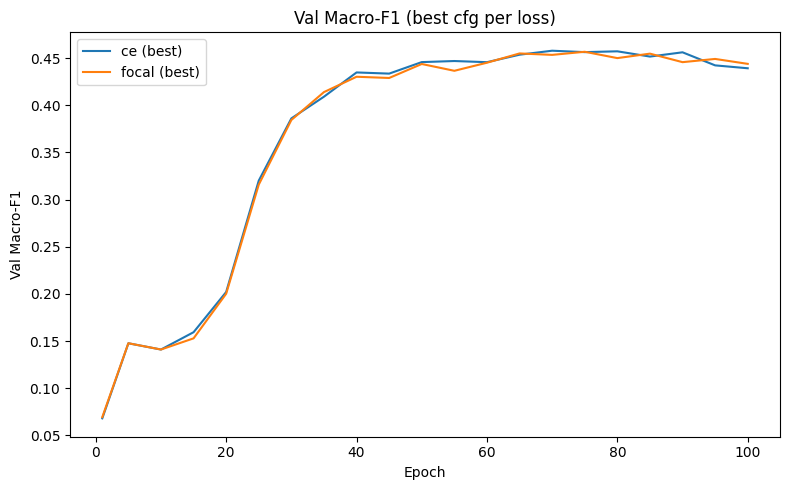

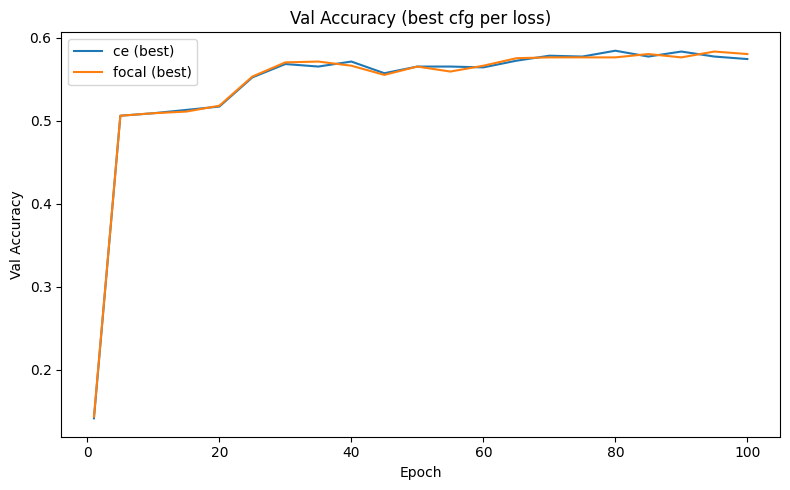

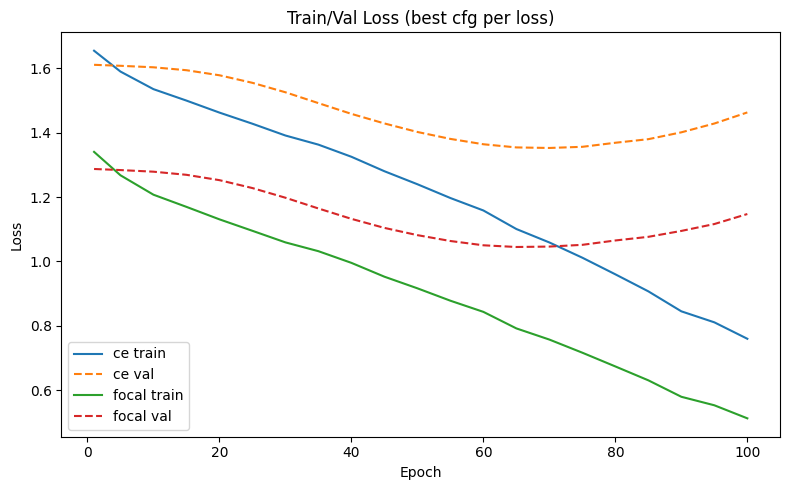


=== Best overall config (avg across seeds/folds) ===
loss=ce | macro-F1=0.4536 | macro-Recall=0.4666 | weighted-F1=0.5831 | acc=0.5666 | best_ep~78
config: {'lstm_hidden': 128, 'gcn_hidden': 64, 'dropout': 0.4, 'lr': 0.0003, 'weight_decay': 0.0001, 'focal_gamma': 1.0}

Classification report (seed=0, representative fold):
              precision    recall  f1-score   support

           0     0.8422    0.7490    0.7929       506
           1     0.3814    0.3543    0.3673       127
           2     0.3206    0.3925    0.3529       107
           3     0.4596    0.5139    0.4852       144
           4     0.2647    0.3214    0.2903       112

    accuracy                         0.5783       996
   macro avg     0.4537    0.4662    0.4577       996
weighted avg     0.6072    0.5783    0.5904       996


Confusion Matrix (seed=0, representative fold): rows=true, cols=pred, labels=0..C-1
[[379  32  22  34  39]
 [ 16  45  34  19  13]
 [ 11  13  42  13  28]
 [ 23  13  14  74  20]
 [ 21  15 

In [9]:
print("\n=== Top 5 configurations (by avg macro-F1 across seeds/folds) ===")
for i, r in enumerate(results_sorted[:5], 1):
    cfg_txt = ", ".join([
        f"lstm={r['cfg']['lstm_hidden']}",
        f"gcn={r['cfg']['gcn_hidden']}",
        f"dropout={r['cfg']['dropout']}",
        f"lr={r['cfg']['lr']}",
        f"wd={r['cfg']['weight_decay']}",
        f"gamma={r['cfg']['focal_gamma']}",
    ])
    print(f"{i:>2}. loss={r['loss']:>12} | macro-F1={r['avg_macro_f1']:.4f} | "
          f"macro-Recall={r['avg_macro_recall']:.4f} | weighted-F1={r['avg_weighted_f1']:.4f} | "
          f"acc={r['avg_acc']:.4f} | best_ep~{r['avg_best_epoch']} | {cfg_txt}")

# Pick best per-loss for curves
best_by_loss = {}
for r in results_sorted:
    key = r["loss"]
    if key not in best_by_loss:
        best_by_loss[key] = r

# Plots: Val Macro-F1 / Val Accuracy / Loss curves
plt.figure(figsize=(8,5))
for name, r in best_by_loss.items():
    plt.plot(r["history"]["epoch"], r["history"]["val_macro_f1"], label=f"{name} (best)")
plt.xlabel("Epoch"); plt.ylabel("Val Macro-F1"); plt.title("Val Macro-F1 (best cfg per loss)")
plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(8,5))
for name, r in best_by_loss.items():
    plt.plot(r["history"]["epoch"], r["history"]["val_acc"], label=f"{name} (best)")
plt.xlabel("Epoch"); plt.ylabel("Val Accuracy"); plt.title("Val Accuracy (best cfg per loss)")
plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(8,5))
for name, r in best_by_loss.items():
    plt.plot(r["history"]["epoch"], r["history"]["train_loss"], label=f"{name} train")
    plt.plot(r["history"]["epoch"], r["history"]["val_loss"], linestyle="--", label=f"{name} val")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Train/Val Loss (best cfg per loss)")
plt.legend(); plt.tight_layout(); plt.show()

# ---- Print classification report and confusion matrix for overall best (seed0 view) ----
best_overall = results_sorted[0]
print("\n=== Best overall config (avg across seeds/folds) ===")
print(f"loss={best_overall['loss']} | macro-F1={best_overall['avg_macro_f1']:.4f} | "
      f"macro-Recall={best_overall['avg_macro_recall']:.4f} | weighted-F1={best_overall['avg_weighted_f1']:.4f} | "
      f"acc={best_overall['avg_acc']:.4f} | best_ep~{best_overall['avg_best_epoch']}")
print("config:", best_overall["cfg"])

print("\nClassification report (seed=0, representative fold):")
print(best_overall["report_seed0"])

print("\nConfusion Matrix (seed=0, representative fold): rows=true, cols=pred, labels=0..C-1")
print(best_overall["cm_seed0"])